# IMPORTS

In [1]:
import glob
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
import numpy as np
from sklearn import tree
from scipy.ndimage import gaussian_filter1d
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier,export_graphviz
from sklearn.model_selection import train_test_split

# FILTERS

In [2]:
# Signal processing
def bandpass_filter(data, lowcut, highcut, fs, order=2):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, data)

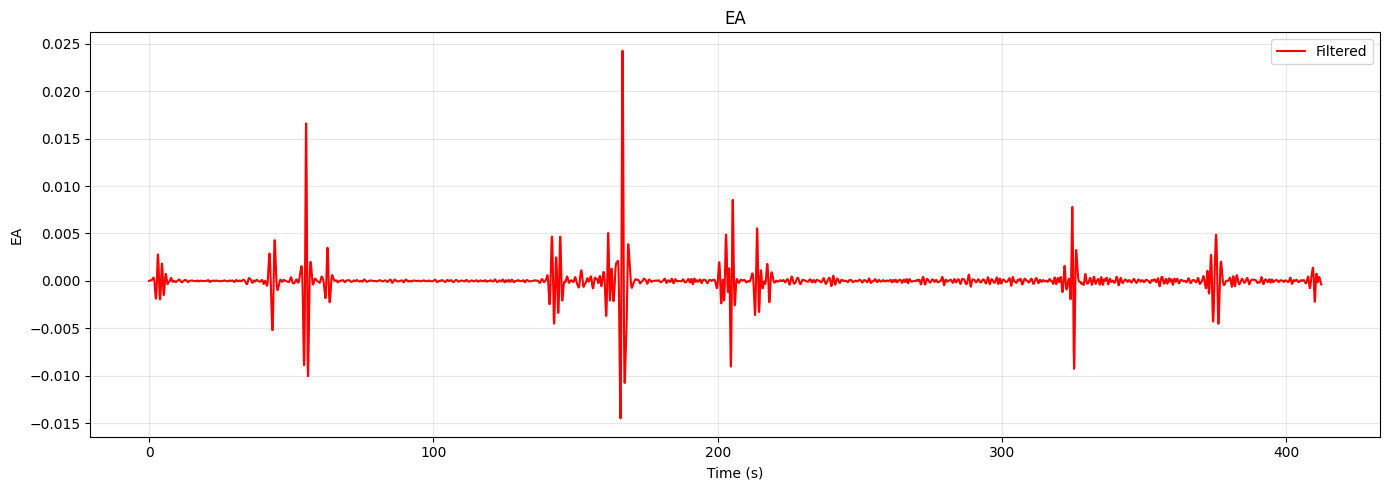

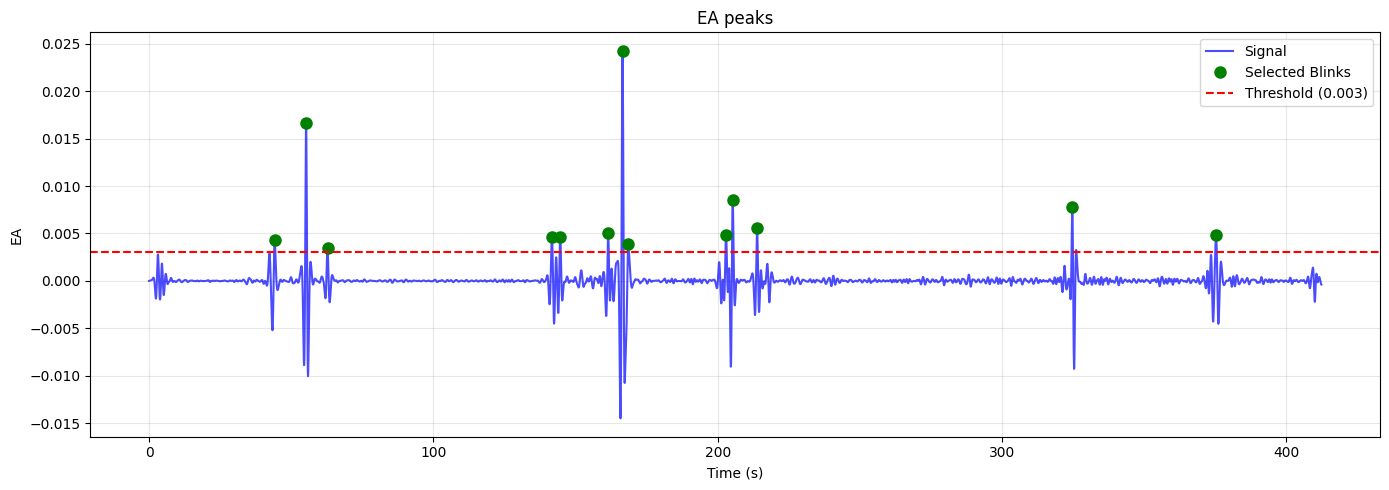

In [3]:
def ea_detection(csv_file_path):
    # Load data
    df = pd.read_csv(csv_file_path)
    df['time[s]'] = (df['LocalTimestamp'] - df['LocalTimestamp'].iloc[0])
    
    ea_raw = df['EA'].astype(float)
    time = df['time[s]']
    sampling_rate = 15
    
    ea_filtered = bandpass_filter(ea_raw, 0.5, 5, sampling_rate)
    smoothed = gaussian_filter1d(ea_filtered, sigma=5)
    window_size = int(0.08 * sampling_rate)
    

    plt.figure(figsize=(14, 5))
    plt.plot(time, smoothed, label="Filtered", color = 'red')
    plt.title("EA")
    plt.xlabel("Time (s)")
    plt.ylabel("EA")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # More sensitive detection parameters
    inverted_signal = smoothed
    HEIGHT_THRESHOLD = 0.003  # Reduced from 18
    PROMINENCE_THRESHOLD = 0  # Reduced from 12
    MIN_BLINK_WIDTH = 0      # Reduced from 5
    MAX_BLINK_WIDTH = 400   # Increased from 150
    MIN_DISTANCE_SEC = 0.1   # Reduced from 0.4
    
    min_distance_samples = int(MIN_DISTANCE_SEC * sampling_rate)
    
    peaks, properties = find_peaks(
        inverted_signal,
        height=HEIGHT_THRESHOLD,
        prominence=PROMINENCE_THRESHOLD,
        distance=min_distance_samples,
        width=(MIN_BLINK_WIDTH, MAX_BLINK_WIDTH)
    )
    
    # Quick quality filter
    good_peaks = []
    for peak in peaks:
        # Check depth
        depth = abs(smoothed[peak] - np.median(smoothed))
        if depth > 0.001:  # Minimum depth threshold
            good_peaks.append(peak)

    # Plot results
    plt.figure(figsize=(14, 5))
    plt.plot(time, smoothed, label='Signal', color='blue', alpha=0.7)
    plt.plot(time.iloc[good_peaks], smoothed[good_peaks], 'go', 
             markersize=8, label='Selected Blinks')
    plt.axhline(HEIGHT_THRESHOLD, color='red', linestyle='--', label=f'Threshold ({HEIGHT_THRESHOLD})')
    plt.title("EA peaks")
    plt.xlabel("Time (s)")
    plt.ylabel("EA")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Run detection
csv_file_path = 'EA.csv'
ea_detection(csv_file_path)